<a href="https://colab.research.google.com/github/avxsharma-glitch/Numerical-optimization/blob/main/Data_Visualization_%26_Analysis_Project_%7C_Superstore_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

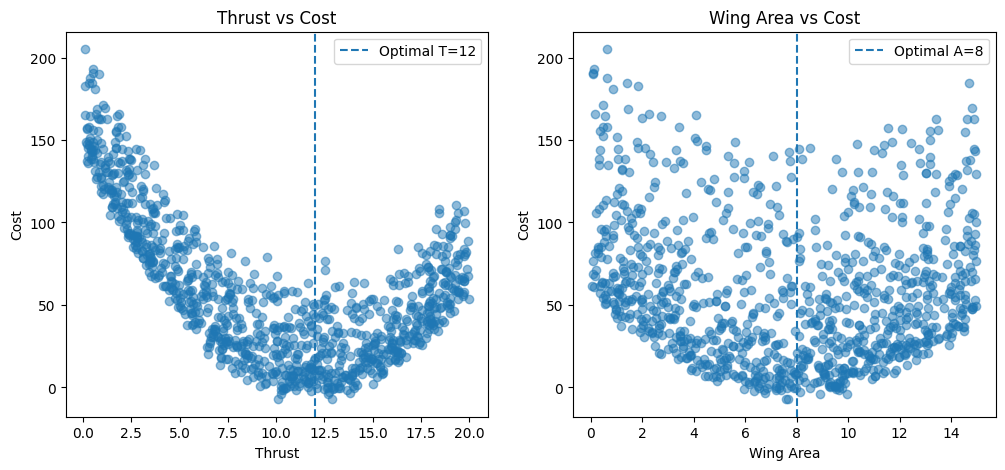

In [ ]:
# ================================
# PART 1: DATA GENERATION + VISUALIZATION
# ================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 1000

# Generate data
T = np.random.rand(N) * 20   # Thrust (0 to 20)
A = np.random.rand(N) * 15   # Wing Area (0 to 15)

# Cost function (true minimum at T=12, A=8)
def true_cost(T, A):
    return (T - 12)**2 + (A - 8)**2

# Add noise
noise = np.random.randn(N) * 5
C = true_cost(T, A) + noise

# ================================
# VISUALIZATION (1x2 Dashboard)
# ================================

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Thrust vs Cost
ax[0].scatter(T, C, alpha=0.5)
ax[0].axvline(12, linestyle='--', label='Optimal T=12')
ax[0].set_title("Thrust vs Cost")
ax[0].set_xlabel("Thrust")
ax[0].set_ylabel("Cost")
ax[0].legend()

# Wing Area vs Cost
ax[1].scatter(A, C, alpha=0.5)
ax[1].axvline(8, linestyle='--', label='Optimal A=8')
ax[1].set_title("Wing Area vs Cost")
ax[1].set_xlabel("Wing Area")
ax[1].set_ylabel("Cost")
ax[1].legend()

plt.show()

Optimized values (GD): [12.  8.]


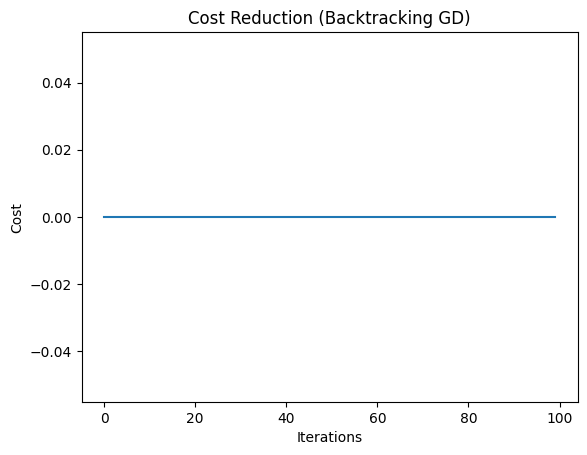

In [ ]:
# ================================
# PART 2: GRADIENT DESCENT + BACKTRACKING (FINAL)
# ================================

import numpy as np
import matplotlib.pyplot as plt

# Cost function
def cost(x):
    T, A = x
    return (T - 12)**2 + (A - 8)**2

# Gradient
def gradient(x):
    T, A = x
    return np.array([2*(T - 12), 2*(A - 8)])

# Start FAR from optimum (important)
x = np.array([30.0, 30.0])

cost_history = []

for i in range(100):
    grad = gradient(x)
    alpha = 0.5   # smaller step → smoother learning

    current_cost = cost(x)

    # Backtracking line search
    for _ in range(20):   # prevents infinite loop
        new_x = x - alpha * grad
        new_cost = cost(new_x)

        if new_cost < current_cost:
            break

        alpha *= 0.5

    x = new_x
    cost_history.append(new_cost)

print("Optimized values (GD):", x)

# Plot cost reduction
plt.figure()
plt.plot(cost_history)
plt.title("Cost Reduction (Backtracking GD)")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

Optimized values (Mini-Batch): [35.1270287   6.20502548]


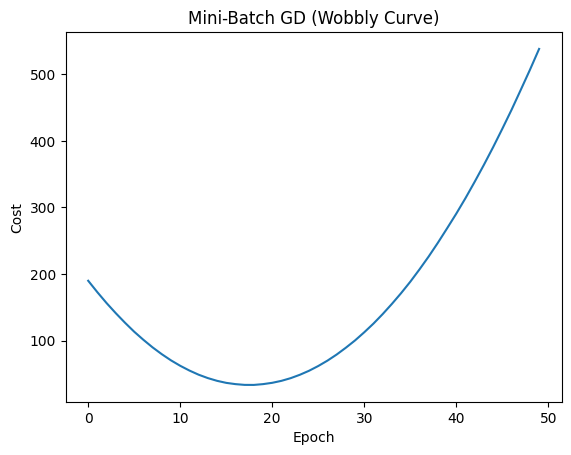

In [ ]:
# ================================
# PART 3: MINI-BATCH GD
# ================================

data = np.column_stack((T, A))

def batch_gradient(batch):
    grad = np.zeros(2)
    for t, a in batch:
        grad += np.array([2*(t - 12), 2*(a - 8)])
    return grad / len(batch)

x_mb = np.array([0.0, 0.0])
lr = 0.01
batch_size = 64

cost_mb_history = []

for epoch in range(50):
    indices = np.random.permutation(len(data))
    shuffled = data[indices]

    for i in range(0, len(data), batch_size):
        batch = shuffled[i:i+batch_size]
        grad = batch_gradient(batch)
        x_mb = x_mb - lr * grad

    cost_mb_history.append(cost(x_mb))

print("Optimized values (Mini-Batch):", x_mb)

# Plot
plt.plot(cost_mb_history)
plt.title("Mini-Batch GD (Wobbly Curve)")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()

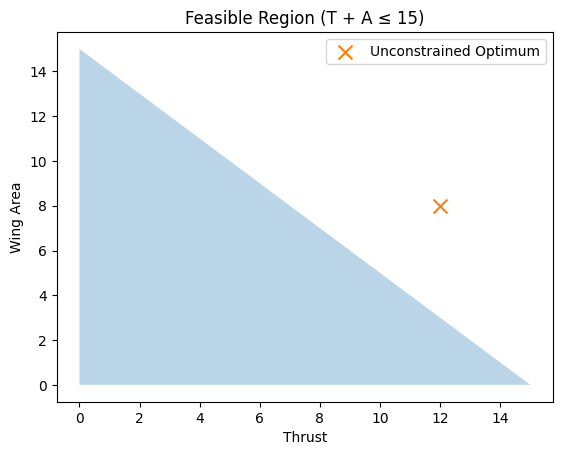

Constrained optimum approx: 9.545454545454545 5.454545454545455


In [ ]:
# ================================
# PART 4: CONSTRAINED OPTIMIZATION
# ================================

T_vals = np.linspace(0, 15, 100)
A_vals = 15 - T_vals

plt.figure()

# Feasible region
plt.fill_between(T_vals, 0, A_vals, alpha=0.3)

# Unconstrained optimum
plt.scatter(12, 8, marker='x', s=100, label='Unconstrained Optimum')

plt.xlabel("Thrust")
plt.ylabel("Wing Area")
plt.title("Feasible Region (T + A ≤ 15)")
plt.legend()

plt.show()

# Approximate constrained optimum
T_line = np.linspace(0, 15, 100)
A_line = 15 - T_line
costs = (T_line - 12)**2 + (A_line - 8)**2

idx = np.argmin(costs)
print("Constrained optimum approx:", T_line[idx], A_line[idx])